# Rolling Walk-Forward (Experiment 3) -- EDA

Visualises `run_rolling_walk_forward_experiment`
(`thesis.system_eval.rolling_walk_forward`): the timeline is walked one
window at a time, mining+fitting from scratch on the *full* window `Wi` and
evaluating on `W(i+1)`, then discarding and repeating -- the "always
retrain" anchor, contrasted against `01_temporal_decay.ipynb`'s frozen-model
decay curve (Experiment 2).

**A structural caveat that matters for every comparison below.** Experiment
2 (in `baseline_split` mode) walks only the *post-split* tail -- `W_src` is
everything before the CSCAS baseline's own train/test boundary, held out of
the walk entirely. Experiment 3 has no such split: it walks the *whole*
timeline from t=0. At a given granularity the two happen to produce the
**same window count** (verified: 21 windows at gran 0.1, 11... wait, see
below), but window *i* in one experiment is **not** the same calendar
window as window *i* in the other. So every plot that puts both experiments
on one axis here uses **fraction of the way through each experiment's own
walk** (0 = the first evaluated window, 1 = the last) rather than the raw
window index -- the only axis the two walks genuinely share.

Sections:
- **§1** detection quality vs. step, one line per granularity (same
  panel-per-model layout as Experiment 2's decay plot), for AUC / F1 / FPR.
- **§2** the walk-forward summary table + bar chart (mean ± std per config
  -- the headline "how good is this in general" number).
- **§3** the always-retrain curve overlaid directly on Experiment 2's
  frozen-decay curve, with a shaded ±1 std band around the always-retrain
  line showing the step-to-step spread that persists even under constant
  retraining.

In [10]:
from __future__ import annotations

%matplotlib inline
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thesis.experiments._shared import METRIC_COLS
from thesis.paths import RESULTS_DIR, ROOT

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

## Config

Edit and re-run -- nothing past the loader cell needs changing.

In [11]:
SCENARIO = "cscas"
RUN_ID = None            # None -> latest rolling-walk-forward run for SCENARIO
GRANULARITY = None       # None -> finest available

# Experiment 2 (frozen decay) run to compare against in §3. None -> latest
# temporal-decay run for the same SCENARIO. Set COMPARE_TO_TEMPORAL_DECAY =
# False to skip §3 entirely (e.g. no matching Exp2 run available).
COMPARE_TO_TEMPORAL_DECAY = True
TEMPORAL_DECAY_RUN_ID = None

PRIMARY_METRIC = "f1"    # §1/§3 default metric when not explicitly looped
MINING_SETTING = None    # which symbolic-family mining setting to use where
                         # one must be picked -- None -> first available

IMG_DIR = ROOT / "src/thesis/notebooks/experiments/img/exp2"
SAVE_FIGS = True
SAVE_DPI = 150

# Same schema vocabulary/colours as 01_temporal_decay.ipynb, kept in sync so
# figures from the two notebooks read as one system.
FEATURE_SET_ORDER = ["baseline", "symbolic", "cscas_full", "cscas_full_symbolic"]
FEATURE_SET_COLOR = {"baseline": "#BB5566", "symbolic": "#004488",
                     "cscas_full": "#DDAA33", "cscas_full_symbolic": "#228833"}
FEATURE_SET_LABEL = {"baseline": "base", "symbolic": "base_symbolic",
                     "cscas_full": "full", "cscas_full_symbolic": "full_symbolic"}
MODEL_ORDER = ["logreg", "xgboost", "rf", "iforest", "ocsvm"]
MODEL_COLOR = dict(zip(MODEL_ORDER, ["#004488", "#66CCEE", "#CCBB44", "#228833", "#EE6677"]))

# §3 colours: which *experiment* a line belongs to, not which schema/model --
# schema/model are already fixed per panel/call there.
EXP2_COLOR = "#CC3311"  # frozen schema (never retrain)
EXP3_COLOR = "#004488"  # always retrain

In [12]:
CONFIG_COLS = ["feature_set", "mining_setting", "granularity", "model"]

sweep_dir = RESULTS_DIR / "sys-eval" / "rolling-walk-forward" / SCENARIO
run_dirs = sorted(p for p in sweep_dir.iterdir() if p.is_dir())
run_dir = (sweep_dir / RUN_ID) if RUN_ID else run_dirs[-1]


def _read_csv_maybe_empty(path) -> pd.DataFrame:
    try:
        return pd.read_csv(path, low_memory=False)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


per_step = pd.read_csv(run_dir / "per_step_results.csv", low_memory=False)
walk_forward_summary = pd.read_csv(run_dir / "walk_forward_summary.csv")
explanations = _read_csv_maybe_empty(run_dir / "explanations.csv")
lime_fidelity = _read_csv_maybe_empty(run_dir / "lime_fidelity.csv")
HAS_EXPLANATIONS = not explanations.empty

print(f"Exp3 run: {run_dir.name}")
print(f"  per_step_results   : {len(per_step):>6} rows")
print(f"  walk_forward_summary: {len(walk_forward_summary):>6} rows")
print(f"  explanations        : {len(explanations):>6} rows")
print(f"  feature_sets : {sorted(per_step['feature_set'].unique())}")
print(f"  models       : {sorted(per_step['model'].unique())}")
print(f"  granularities: {sorted(per_step['granularity'].unique())}")
print(f"  mining setts : {sorted(per_step['mining_setting'].dropna().unique())}")

# Experiment 2 (frozen decay), for §3 -- graceful no-op if unavailable.
HAS_TEMPORAL_DECAY = False
per_horizon = decay_summary = pd.DataFrame()
if COMPARE_TO_TEMPORAL_DECAY:
    td_dir = RESULTS_DIR / "sys-eval" / "temporal-decay" / SCENARIO
    td_run_dirs = sorted(p for p in td_dir.iterdir() if p.is_dir()) if td_dir.exists() else []
    if td_run_dirs:
        td_run_dir = (td_dir / TEMPORAL_DECAY_RUN_ID) if TEMPORAL_DECAY_RUN_ID else td_run_dirs[-1]
        if (td_run_dir / "per_horizon_results.csv").exists():
            per_horizon = pd.read_csv(td_run_dir / "per_horizon_results.csv", low_memory=False)
            decay_summary = pd.read_csv(td_run_dir / "decay_summary.csv")
            HAS_TEMPORAL_DECAY = True
            print(f"\nExp2 run (for §3): {td_run_dir.name}")
            print(f"  per_horizon_results: {len(per_horizon):>6} rows")
        else:
            print(f"\n[warn] no per_horizon_results.csv in {td_run_dir} -- §3 will be skipped")
    else:
        print(f"\n[warn] no temporal-decay runs found at {td_dir} -- §3 will be skipped")
else:
    print("\nCOMPARE_TO_TEMPORAL_DECAY is False -- §3 will be skipped")

Exp3 run: 20260921_142835
  per_step_results   :    240 rows
  walk_forward_summary:     16 rows
  explanations        :  28904 rows
  feature_sets : ['baseline', 'cscas_full', 'cscas_full_symbolic', 'symbolic']
  models       : ['rf', 'xgboost']
  granularities: [0.05, 0.1]
  mining setts : ['gr3_md1_mda4_rounds2']

Exp2 run (for §3): 20260919_200100
  per_horizon_results:    256 rows


## Shared helpers

In [13]:
IMG_DIR.mkdir(parents=True, exist_ok=True)


def _slugify(*parts) -> str:
    bits = []
    for p in parts:
        if p is None or p == "":
            continue
        s = re.sub(r"[^A-Za-z0-9_.=-]+", "_", str(p)).strip("_")
        if s:
            bits.append(s)
    return "_".join(bits)


def save_fig(fig, *name_parts) -> Path | None:
    """Save `fig` to IMG_DIR as <SCENARIO>_<name_parts...>.png. No-op if
    SAVE_FIGS is False."""
    if not SAVE_FIGS:
        return None
    path = IMG_DIR / f"{_slugify(SCENARIO, *name_parts)}.png"
    fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight")
    print(f"  saved -> {path.relative_to(ROOT)}")
    return path


def fs_label(fs) -> str:
    return FEATURE_SET_LABEL.get(fs, fs)


def ms_short(ms) -> str:
    if ms is None or (isinstance(ms, float) and np.isnan(ms)):
        return ""
    ms = str(ms)
    return ms[4:].replace("_", "/") if ms.startswith("gr3_") else ms.replace("_", "/")


def resolve_gran() -> float:
    grans = sorted(per_step["granularity"].unique())
    if GRANULARITY is None:
        return grans[0]
    if GRANULARITY not in grans:
        raise ValueError(f"GRANULARITY={GRANULARITY} not in run ({grans})")
    return GRANULARITY


GRAN = resolve_gran()
ALL_GRANULARITIES = sorted(per_step["granularity"].unique())
FEATURE_SETS = [fs for fs in FEATURE_SET_ORDER if fs in set(per_step["feature_set"])]
MODELS = [m for m in MODEL_ORDER if m in set(per_step["model"])]
_unknown_models = sorted(set(per_step["model"]) - set(MODEL_ORDER))
if _unknown_models:
    _extra_pal = plt.get_cmap("tab10")
    for _i, _m in enumerate(_unknown_models):
        MODEL_COLOR[_m] = _extra_pal(_i % 10)
    MODELS += _unknown_models
MINING_SETTINGS = sorted(per_step.loc[per_step["feature_set"] == "symbolic", "mining_setting"].dropna().unique())
MS_ONE = MINING_SETTING or (MINING_SETTINGS[0] if MINING_SETTINGS else None)

# step_i runs 0 .. n_windows-2 (evaluating W(i+1) for i up to the second-to-
# last window) -- step_fraction puts it on the same [0, 1] axis as Exp2's
# native horizon_fraction column, so different granularities (different
# step counts) and different experiments (different walks) can share an
# x-axis. See the title markdown for why raw index isn't safe to share
# across experiments.
per_step["step_fraction"] = per_step["step_i"] / (per_step["n_windows"] - 2)

_gran_pal = plt.get_cmap("plasma")
GRAN_COLOR = dict(zip(
    ALL_GRANULARITIES,
    [_gran_pal(x) for x in np.linspace(0.15, 0.80, max(1, len(ALL_GRANULARITIES)))],
))


def _ms_mask(df: pd.DataFrame, feature_set: str, mining_setting) -> pd.Series:
    """feature_set-and-mining_setting mask, NaN-safe (baseline/cscas_full
    carry no mining_setting -- a plain `==` never matches NaN)."""
    m = df["feature_set"].eq(feature_set)
    if feature_set in ("symbolic", "cscas_full_symbolic"):
        ms = mining_setting or MS_ONE
        m &= df["mining_setting"].eq(ms)
    else:
        m &= df["mining_setting"].isna()
    return m

## 1. Detection quality vs. step, one line per granularity

Same panel layout as Experiment 2's decay plot (one panel per model) -- but
here each **line is a granularity** rather than a schema, since the
question is "does the always-retrain curve look different at a finer vs.
coarser walk", not a schema comparison. `feature_set` is fixed per call
(default `symbolic` if present). x-axis is `step_fraction` (0 = the first
evaluated step, 1 = the last), so gran 0.1's 10 steps and gran 0.05's 20
steps land on the same axis. The shaded band is the IQR across mining
settings at that step (a single setting in this run, so it collapses to the
line -- see `01_temporal_decay.ipynb`'s note on the same point).

  saved -> src/thesis/notebooks/experiments/img/exp2/cscas_sec1_step_metric_base_symbolic_auc.png
  saved -> src/thesis/notebooks/experiments/img/exp2/cscas_sec1_step_metric_base_symbolic_f1.png
  saved -> src/thesis/notebooks/experiments/img/exp2/cscas_sec1_step_metric_base_symbolic_fpr.png


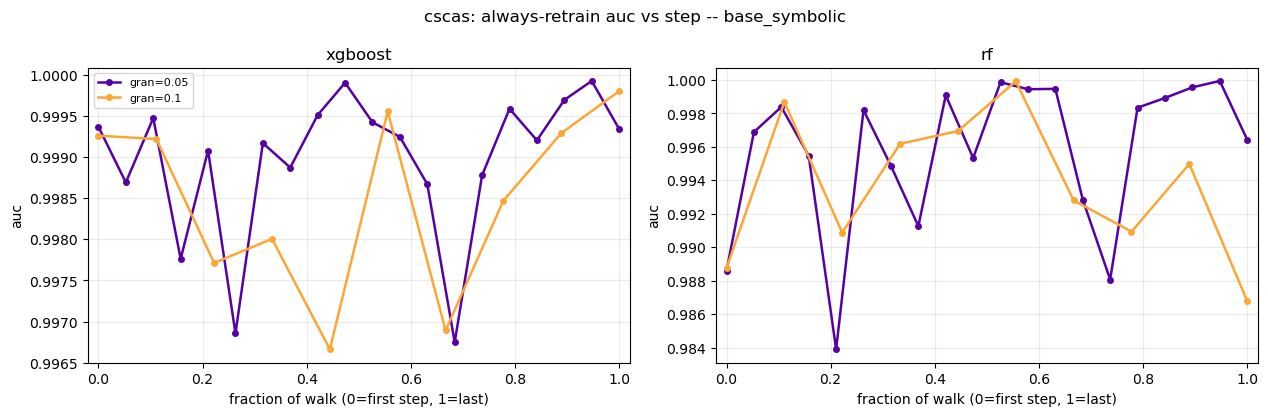

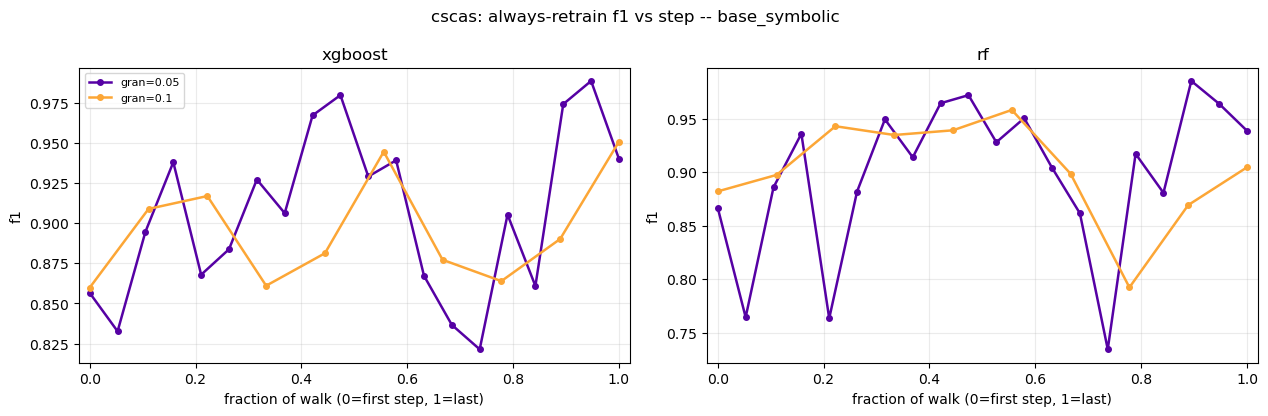

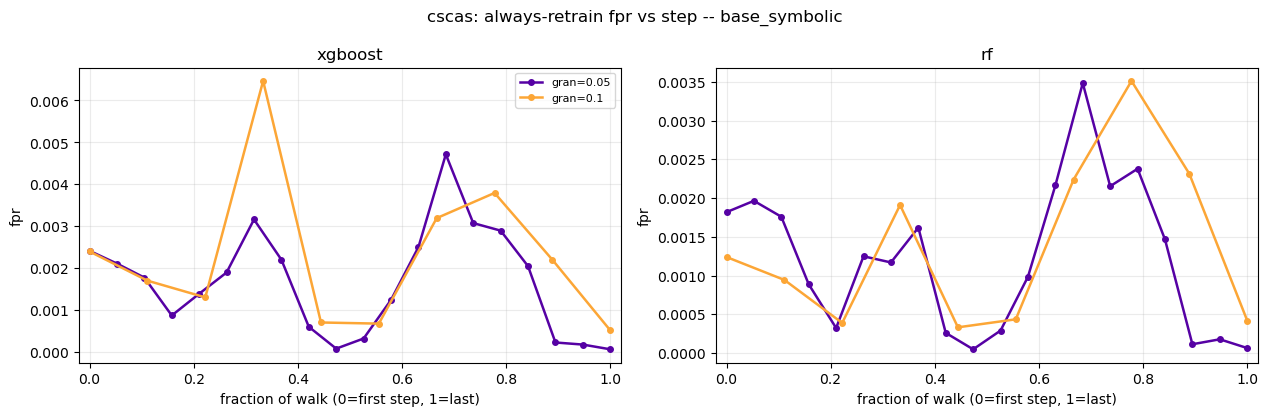

In [14]:
def _step_series(feature_set: str, model: str, metric: str, gran: float, mining_setting=None):
    m = (_ms_mask(per_step, feature_set, mining_setting) & per_step["model"].eq(model)
         & per_step["granularity"].eq(gran))
    sub = per_step[m]
    if sub.empty or metric not in sub:
        return None
    g = sub.groupby("step_fraction")[metric]
    return g.median().index.values, g.median().values, g.quantile(0.25).values, g.quantile(0.75).values


def plot_step_metric_by_granularity(metric: str = None, feature_set: str = None, models=None) -> None:
    metric = metric or PRIMARY_METRIC
    feature_set = feature_set or ("symbolic" if "symbolic" in FEATURE_SETS else FEATURE_SETS[0])
    models = models or MODELS
    ncols = min(2, len(models))
    nrows = -(-len(models) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.4 * ncols, 4.2 * nrows), squeeze=False)
    for ax, model in zip(axes.flat, models):
        any_data = False
        for gran in ALL_GRANULARITIES:
            s = _step_series(feature_set, model, metric, gran)
            if s is None:
                continue
            any_data = True
            h, med, q25, q75 = s
            color = GRAN_COLOR[gran]
            ax.plot(h, med, "-o", ms=4, lw=1.8, color=color, label=f"gran={gran:g}", zorder=3)
            if (q75 > q25).any():
                ax.fill_between(h, q25, q75, color=color, alpha=0.15, lw=0)
        if not any_data:
            ax.text(0.5, 0.5, "no data for this config", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9, color="grey")
        ax.set_title(model)
        ax.set_xlabel("fraction of walk (0=first step, 1=last)")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.25)
        ax.margins(x=0.02)
    for ax in axes.flat[len(models):]:
        ax.set_visible(False)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(f"{SCENARIO}: always-retrain {metric} vs step -- {fs_label(feature_set)}")
    fig.tight_layout()
    save_fig(fig, "sec1", "step_metric", fs_label(feature_set), metric)


plot_step_metric_by_granularity("auc")
plot_step_metric_by_granularity("f1")
plot_step_metric_by_granularity("fpr")

## 2. Walk-forward summary (headline number)

Mean and std of `auc`, `f1`, and `fpr` across every step actually run, one
row per config -- the "how good is this config in general use" number this
experiment exists to produce.

In [15]:
sort_col = f"{PRIMARY_METRIC}_mean"
wfs_view = walk_forward_summary.copy()
wfs_view["schema"] = wfs_view["feature_set"].map(fs_label)
summary_sorted = (
    wfs_view.sort_values(sort_col, ascending=False) if sort_col in wfs_view else wfs_view
)
summary_sorted

,feature_set,mining_setting,granularity,model,auc_mean,auc_std,f1_mean,f1_std,fpr_mean,fpr_std,n_steps,schema
7,cscas_full,NaN,0.10,xgboost,0.999659,0.000339,0.945544,0.033605,0.001090,0.000858,10,full
11,cscas_full_symbolic,gr3_md1_mda4_rounds2,0.10,xgboost,0.999686,0.000331,0.941347,0.035268,0.000988,0.000845,10,full_symbolic
9,cscas_full_symbolic,gr3_md1_mda4_rounds2,0.05,xgboost,0.999662,0.000423,0.931187,0.058275,0.001144,0.001112,20,full_symbolic
5,cscas_full,NaN,0.05,xgboost,0.999575,0.000638,0.928576,0.054124,0.001271,0.001082,20,full
13,symbolic,gr3_md1_mda4_rounds2,0.05,xgboost,0.998967,0.000889,0.905856,0.051506,0.001689,0.001260,20,base_symbolic
10,cscas_full_symbolic,gr3_md1_mda4_rounds2,0.10,rf,0.999679,0.000304,0.904862,0.072046,0.000623,0.000554,10,full_symbolic
14,symbolic,gr3_md1_mda4_rounds2,0.10,rf,0.993689,0.004350,0.902081,0.048138,0.001373,0.001082,10,base_symbolic
12,symbolic,gr3_md1_mda4_rounds2,0.05,rf,0.995745,0.004580,0.898260,0.071730,0.001219,0.000958,20,base_symbolic
15,symbolic,gr3_md1_mda4_rounds2,0.10,xgboost,0.998488,0.001124,0.895485,0.033560,0.002296,0.001829,10,base_symbolic
6,cscas_full,NaN,0.10,rf,0.999587,0.000349,0.884578,0.081311,0.000663,0.000540,10,full


  saved -> src/thesis/notebooks/experiments/img/exp2/cscas_sec2_walk_forward_summary_f1.png


PosixPath('/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/notebooks/experiments/img/exp2/cscas_sec2_walk_forward_summary_f1.png')

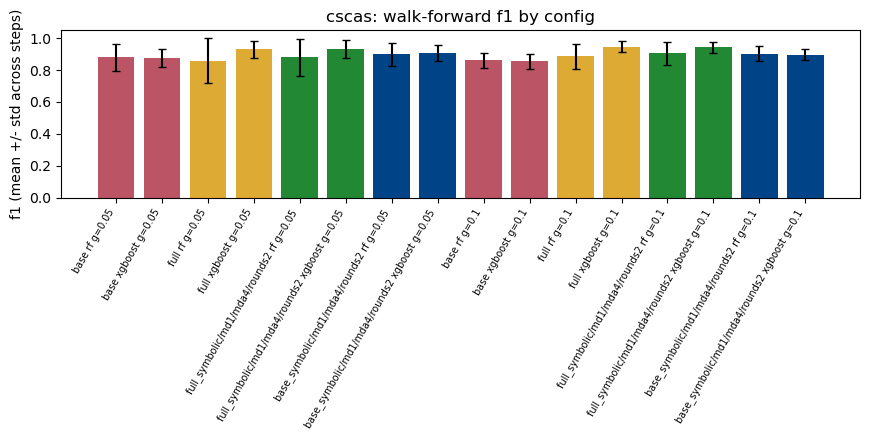

In [16]:
def config_label(row) -> str:
    ms = f"/{ms_short(row['mining_setting'])}" if pd.notna(row["mining_setting"]) else ""
    return f"{fs_label(row['feature_set'])}{ms} {row['model']} g={row['granularity']:g}"


mean_col, std_col = f"{PRIMARY_METRIC}_mean", f"{PRIMARY_METRIC}_std"
plot_order = summary_sorted.sort_values(["granularity", "feature_set", "mining_setting", "model"]).reset_index(drop=True)
labels = plot_order.apply(config_label, axis=1)
colors = [FEATURE_SET_COLOR[fs] for fs in plot_order["feature_set"]]

fig, ax = plt.subplots(figsize=(max(6, 0.55 * len(plot_order)), 4.5))
ax.bar(labels, plot_order[mean_col], yerr=plot_order[std_col], color=colors, capsize=3)
ax.set_ylabel(f"{PRIMARY_METRIC} (mean +/- std across steps)")
ax.set_title(f"{SCENARIO}: walk-forward {PRIMARY_METRIC} by config")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right", fontsize=7)
fig.tight_layout()
save_fig(fig, "sec2", "walk_forward_summary", PRIMARY_METRIC)

## 3. Frozen decay vs. always-retrain, overlaid

Experiment 2's frozen-schema decay curve and Experiment 3's always-retrain
curve, **on the same axes** (fraction of the way through each experiment's
own walk -- see the title markdown for why raw step/horizon index isn't
shared between them), for a fixed schema and granularity, one panel per
model. The shaded band around the always-retrain line is its mean ± 1 std
across every step actually run (from `walk_forward_summary` -- the
"steady-state" spread that persists even though every step retrains from
scratch), so a reader can see whether the frozen curve's decay ever crosses
into that band, not just where the two curves' endpoints land.

  saved -> src/thesis/notebooks/experiments/img/exp2/cscas_sec3_frozen_vs_retrain_base_symbolic_auc_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp2/cscas_sec3_frozen_vs_retrain_base_symbolic_f1_gran=0.05.png
  saved -> src/thesis/notebooks/experiments/img/exp2/cscas_sec3_frozen_vs_retrain_base_symbolic_fpr_gran=0.05.png


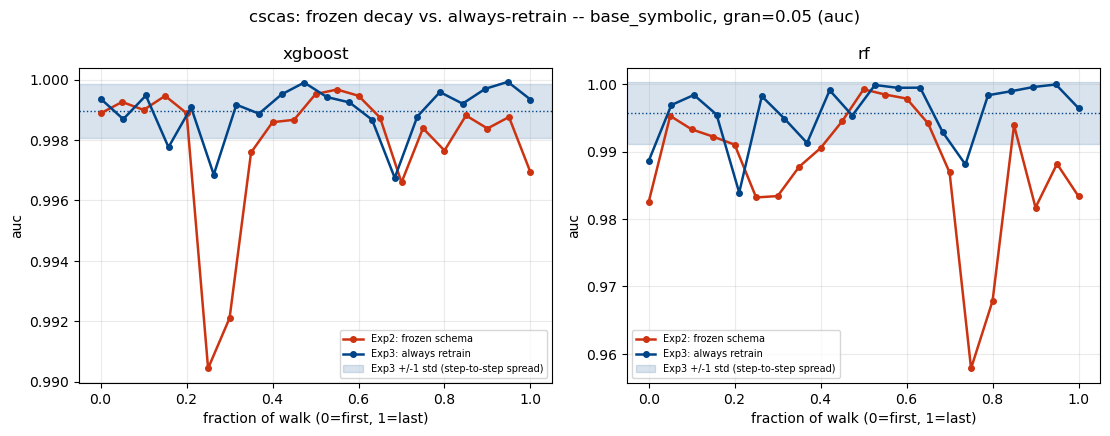

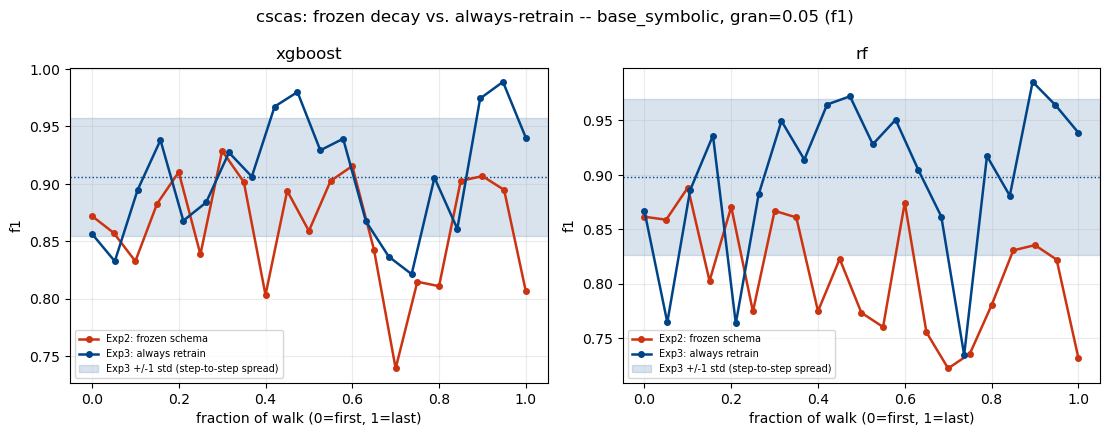

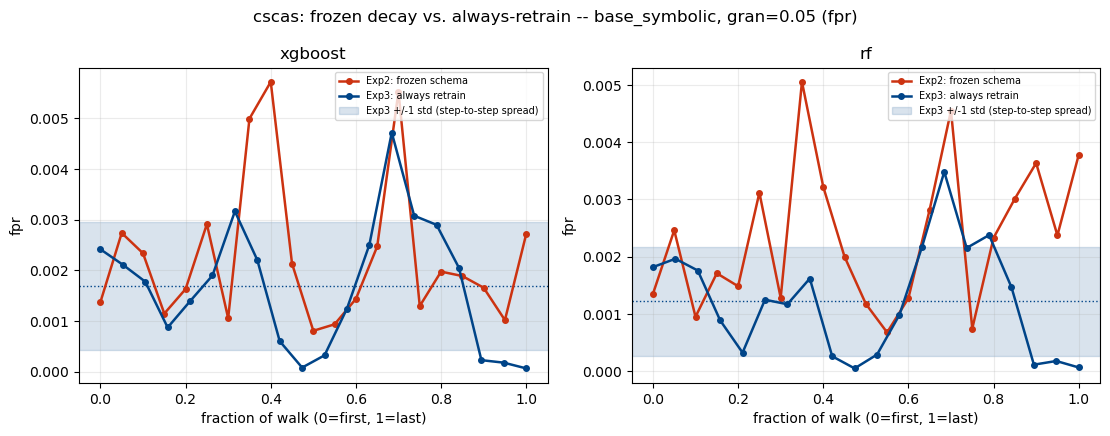

In [17]:
def _horizon_series(feature_set: str, model: str, metric: str, gran: float, mining_setting=None):
    if not HAS_TEMPORAL_DECAY:
        return None
    m = (_ms_mask(per_horizon, feature_set, mining_setting) & per_horizon["model"].eq(model)
         & per_horizon["granularity"].eq(gran))
    sub = per_horizon[m]
    if sub.empty or metric not in sub or "horizon_fraction" not in sub:
        return None
    g = sub.groupby("horizon_fraction")[metric]
    return g.median().index.values, g.median().values


def _wfs_mean_std(feature_set: str, model: str, metric: str, gran: float, mining_setting=None):
    m = (_ms_mask(walk_forward_summary, feature_set, mining_setting) & walk_forward_summary["model"].eq(model)
         & walk_forward_summary["granularity"].eq(gran))
    sub = walk_forward_summary[m]
    mcol, scol = f"{metric}_mean", f"{metric}_std"
    if sub.empty or mcol not in sub:
        return None
    row = sub.iloc[0]
    return float(row[mcol]), (float(row[scol]) if pd.notna(row.get(scol)) else 0.0)


def plot_frozen_vs_retrain(metric: str = None, feature_set: str = None, granularity: float = None,
                           models=None, show_band: bool = True) -> None:
    if not HAS_TEMPORAL_DECAY:
        print("no matching temporal-decay run loaded (COMPARE_TO_TEMPORAL_DECAY=False, or none found) -- skipping")
        return
    metric = metric or PRIMARY_METRIC
    feature_set = feature_set or ("symbolic" if "symbolic" in FEATURE_SETS else FEATURE_SETS[0])
    granularity = granularity or GRAN
    models = models or MODELS
    fig, axes = plt.subplots(1, len(models), figsize=(5.6 * len(models), 4.4), squeeze=False, sharey=False)
    for ax, model in zip(axes[0], models):
        e2 = _horizon_series(feature_set, model, metric, granularity)
        if e2 is not None:
            ax.plot(e2[0], e2[1], "-o", ms=4, lw=1.8, color=EXP2_COLOR,
                    label="Exp2: frozen schema", zorder=3)
        else:
            ax.text(0.5, 0.7, "no Exp2 data for this config", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color=EXP2_COLOR)
        e3 = _step_series(feature_set, model, metric, granularity)
        if e3 is not None:
            h3, med3, _, _ = e3
            ax.plot(h3, med3, "-o", ms=4, lw=1.8, color=EXP3_COLOR,
                    label="Exp3: always retrain", zorder=3)
        else:
            ax.text(0.5, 0.3, "no Exp3 data for this config", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color=EXP3_COLOR)
        if show_band:
            ms = _wfs_mean_std(feature_set, model, metric, granularity)
            if ms is not None:
                mean_v, std_v = ms
                ax.axhspan(mean_v - std_v, mean_v + std_v, color=EXP3_COLOR, alpha=0.15, zorder=1,
                          label="Exp3 +/-1 std (step-to-step spread)")
                ax.axhline(mean_v, color=EXP3_COLOR, lw=1, ls=":", zorder=2)
        ax.set_title(model)
        ax.set_xlabel("fraction of walk (0=first, 1=last)")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7)
    fig.suptitle(f"{SCENARIO}: frozen decay vs. always-retrain -- "
                f"{fs_label(feature_set)}, gran={granularity:g} ({metric})")
    fig.tight_layout()
    save_fig(fig, "sec3", "frozen_vs_retrain", fs_label(feature_set), metric, f"gran={granularity:g}")


plot_frozen_vs_retrain("auc")
plot_frozen_vs_retrain("f1")
plot_frozen_vs_retrain("fpr")

In [18]:
# Numeric companion to the plot above: Exp2's h=0 (best case, before decay)
# and h=h_max (frozen, fully decayed) vs. Exp3's steady-state mean, per
# config -- the always-retrain gain a perfect retraining policy buys over
# never retraining, the number Experiment 4's drift monitor is compared
# against.
comparison = None
if HAS_TEMPORAL_DECAY and not decay_summary.empty:
    ds = decay_summary.copy()
    ds[f"{PRIMARY_METRIC}_at_h_max"] = ds.apply(
        lambda r: r.get(f"{PRIMARY_METRIC}_at_h{int(r['h_max'])}", np.nan), axis=1
    )
    comparison = walk_forward_summary.merge(
        ds[CONFIG_COLS + [f"{PRIMARY_METRIC}_at_h0", f"{PRIMARY_METRIC}_at_h_max"]],
        on=CONFIG_COLS, how="inner",
    )
    comparison["always_retrain_gain"] = (
        comparison[f"{PRIMARY_METRIC}_mean"] - comparison[f"{PRIMARY_METRIC}_at_h_max"]
    )
    comparison["schema"] = comparison["feature_set"].map(fs_label)
    print(f"{len(comparison)}/{len(walk_forward_summary)} configs matched by "
          "(feature_set, mining_setting, granularity, model)")
else:
    print("no comparison table -- §3's plot above already covers the same ground visually")
comparison

16/16 configs matched by (feature_set, mining_setting, granularity, model)


,feature_set,mining_setting,granularity,model,auc_mean,auc_std,f1_mean,f1_std,fpr_mean,fpr_std,n_steps,f1_at_h0,f1_at_h_max,always_retrain_gain,schema
0,baseline,NaN,0.05,rf,0.994065,0.005272,0.878489,0.084100,0.001690,0.001856,20,0.874317,0.561488,0.317002,base
1,baseline,NaN,0.05,xgboost,0.998132,0.001640,0.876279,0.056073,0.003106,0.003312,20,0.813810,0.700173,0.176106,base
2,baseline,NaN,0.10,rf,0.993093,0.004443,0.860485,0.048757,0.002475,0.002465,10,0.874317,0.630329,0.230156,base
3,baseline,NaN,0.10,xgboost,0.998574,0.001150,0.855006,0.046427,0.003749,0.002270,10,0.813810,0.755542,0.099463,base
4,cscas_full,NaN,0.05,rf,0.999432,0.000729,0.859272,0.139166,0.000831,0.001074,20,0.783593,0.826531,0.032742,full
5,cscas_full,NaN,0.05,xgboost,0.999575,0.000638,0.928576,0.054124,0.001271,0.001082,20,0.894244,0.691194,0.237382,full
6,cscas_full,NaN,0.10,rf,0.999587,0.000349,0.884578,0.081311,0.000663,0.000540,10,0.783593,0.884062,0.000516,full
7,cscas_full,NaN,0.10,xgboost,0.999659,0.000339,0.945544,0.033605,0.001090,0.000858,10,0.894244,0.772727,0.172817,full
8,cscas_full_symbolic,gr3_md1_mda4_rounds2,0.05,rf,0.999628,0.000383,0.879570,0.115585,0.000587,0.000534,20,0.813559,0.844642,0.034928,full_symbolic
9,cscas_full_symbolic,gr3_md1_mda4_rounds2,0.05,xgboost,0.999662,0.000423,0.931187,0.058275,0.001144,0.001112,20,0.876783,0.775991,0.155196,full_symbolic
